In [1]:
import pandas as pd
import numpy as np

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
from configs import config

df = pd.read_csv(config.RAW_DATA_FILE)
display(df.head())

,timestamp,Active_Energy_Delivered_Received,Current_Phase_Average,Active_Power,Power_Factor_Signed,Average_Voltage_Line_to_Neutral,Frequency,THD_Voltage_Average,Wind_Speed,Weather_Temperature_Celsius,Weather_Relative_Humidity,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Wind_Direction,Weather_Daily_Rainfall,Radiation_Global_Tilted,Radiation_Diffuse_Tilted
0,2008-09-12 05:55:00,-2.638068,NaN,-0.245161,NaN,250.953476,50.006252,NaN,NaN,25.734350,18.551216,5.227983,2.215820,103.423134,0.0,NaN,NaN
1,2008-09-12 06:00:00,-2.658491,NaN,-0.245080,NaN,250.978424,50.005299,NaN,NaN,25.402353,19.242727,5.408280,2.435364,125.776703,0.0,NaN,NaN
2,2008-09-12 06:05:00,-2.678929,NaN,-0.245251,NaN,250.966934,50.005074,NaN,NaN,25.141418,19.368038,4.931451,1.885518,163.055115,0.0,NaN,NaN
3,2008-09-12 06:10:00,-2.699341,NaN,-0.244939,NaN,250.784180,50.004089,NaN,NaN,25.015263,19.301992,4.298166,1.327833,137.553268,0.0,NaN,NaN
4,2008-09-12 06:15:00,-2.719728,NaN,-0.244650,NaN,250.727081,50.003780,NaN,NaN,24.935015,19.123230,4.499399,1.520790,128.099182,0.0,NaN,NaN


In [4]:
for i, col in enumerate(df.columns):
  print(f"{i+1:3d}.{col}")

  1.timestamp
  2.Active_Energy_Delivered_Received
  3.Current_Phase_Average
  4.Active_Power
  5.Power_Factor_Signed
  6.Average_Voltage_Line_to_Neutral
  7.Frequency
  8.THD_Voltage_Average
  9.Wind_Speed
 10.Weather_Temperature_Celsius
 11.Weather_Relative_Humidity
 12.Global_Horizontal_Radiation
 13.Diffuse_Horizontal_Radiation
 14.Wind_Direction
 15.Weather_Daily_Rainfall
 16.Radiation_Global_Tilted
 17.Radiation_Diffuse_Tilted


In [5]:
num_rows_df= df.shape[0]
num_columns_df = df.shape[1]
print(f'Number of rows in the dataframe: {num_rows_df}')
print(f'Number of columns in the dataframe: {num_columns_df}')

Number of rows in the dataframe: 1767903
Number of columns in the dataframe: 17


In [6]:
missing_percentage_df = (df.isnull().sum()/df.shape[0])*100
print(f'Percentage wise missing columns values: ')
display(missing_percentage_df.sort_values(ascending=False))

Percentage wise missing columns values: 


Wind_Speed                          52.385906
Power_Factor_Signed                 41.218212
THD_Voltage_Average                 41.188685
Current_Phase_Average               41.188685
Radiation_Global_Tilted             36.089933
Radiation_Diffuse_Tilted            33.707053
Wind_Direction                       2.285985
Weather_Temperature_Celsius          2.166578
Weather_Relative_Humidity            2.166069
Diffuse_Horizontal_Radiation         2.163920
Global_Horizontal_Radiation          2.163920
Weather_Daily_Rainfall               2.162506
Frequency                            1.546295
Active_Energy_Delivered_Received     1.536679
Active_Power                         1.534360
Average_Voltage_Line_to_Neutral      1.503872
timestamp                            0.000000
dtype: float64

In [7]:
# Convert timestamp to datetime for temporal analysis.
df["timestamp"] = pd.to_datetime(df["timestamp"])

## Verification of Dataset Consistency

The DKASC combined dataset provides aggregated power from multiple photovoltaic technologies, but the accompanying documentation does not explicitly state whether the same set of technologies is represented throughout the entire observation period. Therefore, yearly maximum power output, average daytime power generation, and annual energy generation were examined to verify that the combined dataset corresponded to a physically consistent PV system. This analysis confirmed that the plant capacity stabilized from 2014 onwards, supporting the selection of 2014–2025 for model development.

In [8]:
#Maximum annual power output (effective plant capacity)

df.groupby(df["timestamp"].dt.year)["Active_Power"].max()

timestamp
2008     96.541840
2009     98.262398
2010    192.496414
2011    197.103165
2012    208.921387
2013    221.668991
2014    241.025787
2015    224.172592
2016    223.143555
2017    229.101715
2018    205.036942
2019    211.258606
2020    215.767670
2021    207.578934
2022    222.692856
2023    216.894684
2024    227.322708
2025    204.643890
Name: Active_Power, dtype: float64

In [9]:
# MEASURES Average daytime power output
# Consider only daylight observations (GHI > 20 W/m²)

daytime = df[df["Global_Horizontal_Radiation"] > 20]

daytime.groupby(daytime["timestamp"].dt.year)["Active_Power"].mean()

timestamp
2008     25.612165
2009     50.942081
2010     70.104767
2011     91.964789
2012     97.376889
2013    103.924367
2014    107.361142
2015    106.039378
2016     99.405258
2017    102.309385
2018    103.393536
2019    110.509955
2020    101.437377
2021     93.380783
2022     98.884450
2023     99.911508
2024     95.425002
2025    102.242802
Name: Active_Power, dtype: float64

In [10]:
# MEASURES Total annual energy generation

df.groupby(df["timestamp"].dt.year)["Active_Power"].sum()

timestamp
2008    4.474691e+05
2009    2.548739e+06
2010    3.485509e+06
2011    4.565020e+06
2012    4.845933e+06
2013    5.156400e+06
2014    5.339773e+06
2015    5.278690e+06
2016    4.885531e+06
2017    5.050584e+06
2018    5.149064e+06
2019    5.402710e+06
2020    5.088424e+06
2021    4.427867e+06
2022    4.824489e+06
2023    4.590222e+06
2024    3.988323e+06
2025    2.791500e+06
Name: Active_Power, dtype: float64

## Target Variable Cleaning

Rows with missing values in the target variable (`Active_Power`) are removed because the target should not be imputed during supervised learning.

In [11]:
# Remove samples where the prediction target is unavailable.
df = df.dropna(subset=["Active_Power"]).reset_index(drop=True)

## Feature Elimination

In [12]:
# Removed because it is an operational electrical measurement rather than an environmental predictor. In addition, more than 41% of observations are missing, making reliable imputation difficult.
df.drop(columns=["Current_Phase_Average"], inplace=True)

In [13]:
# Removed because it represents power quality rather than the environmental conditions governing PV generation. The feature also contains over 41% missing observations.
df.drop(columns=["THD_Voltage_Average"], inplace=True)

In [14]:
# Removed because power factor primarily reflects electrical operating conditions and load characteristics rather than meteorological influences on PV output. The feature also exhibits substantial missingness of over 41%.
df.drop(columns=["Power_Factor_Signed"], inplace=True)

In [15]:
# Removed because over half of the observations are missing. Retaining this variable would require extensive imputation, which could introduce additional uncertainty into the forecasting model.
df.drop(columns=["Wind_Speed"], inplace=True)

In [16]:
# Removed because it is a cumulative energy meter rather than an instantaneous environmental predictor. Since the forecasting target is instantaneous active power, this variable provides limited additional information and may introduce redundancy along with data leakage.
df.drop(columns=["Active_Energy_Delivered_Received"], inplace=True)

## Pearson Correlation Analysis

Pearson's correlation coefficient is computed to examine the linear relationship between each numerical predictor and the target variable (`Active_Power`). This analysis provides an initial indication of feature relevance but is not used as the sole criterion for feature selection and elimination.

In [17]:
# Compute Pearson correlation between each numerical predictor and the target.

correlation_with_target = (
    df.corr(numeric_only=True)["Active_Power"]
      .drop("Active_Power")
      .to_frame(name="Pearson_Correlation")
)

correlation_with_target["Absolute_Correlation"] = (
    correlation_with_target["Pearson_Correlation"].abs()
)

correlation_with_target = correlation_with_target.sort_values(
    "Absolute_Correlation",
    ascending=False
)

display(correlation_with_target)

,Pearson_Correlation,Absolute_Correlation
Radiation_Global_Tilted,0.985039,0.985039
Global_Horizontal_Radiation,0.950372,0.950372
Diffuse_Horizontal_Radiation,0.522721,0.522721
Weather_Relative_Humidity,-0.425073,0.425073
Weather_Temperature_Celsius,0.411703,0.411703
Radiation_Diffuse_Tilted,0.284870,0.284870
Average_Voltage_Line_to_Neutral,0.172694,0.172694
Weather_Daily_Rainfall,-0.049201,0.049201
Wind_Direction,0.018328,0.018328
Frequency,0.011023,0.011023


In [18]:
# Compute Pearson correlation among all numerical predictor variables.

predictor_correlation = (
    df.drop(columns=["Active_Power"])
      .corr(numeric_only=True)
)

display(predictor_correlation)

,Average_Voltage_Line_to_Neutral,Frequency,Weather_Temperature_Celsius,Weather_Relative_Humidity,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,Wind_Direction,Weather_Daily_Rainfall,Radiation_Global_Tilted,Radiation_Diffuse_Tilted
Average_Voltage_Line_to_Neutral,1.000000,0.592579,0.050379,-0.000962,0.189266,0.101954,-0.029922,0.009594,0.525753,0.138911
Frequency,0.592579,1.000000,-0.005506,0.007363,-0.002653,-0.002891,-0.000801,-0.002792,0.002681,0.000521
Weather_Temperature_Celsius,0.050379,-0.005506,1.000000,-0.587803,0.489756,0.395408,-0.019719,-0.008040,0.428438,0.178964
Weather_Relative_Humidity,-0.000962,0.007363,-0.587803,1.000000,-0.440591,-0.224804,0.034716,0.235195,-0.429906,-0.118119
Global_Horizontal_Radiation,0.189266,-0.002653,0.489756,-0.440591,1.000000,0.580072,-0.045969,-0.045145,0.976326,0.295642
Diffuse_Horizontal_Radiation,0.101954,-0.002891,0.395408,-0.224804,0.580072,1.000000,-0.006569,0.047468,0.540838,0.469550
Wind_Direction,-0.029922,-0.000801,-0.019719,0.034716,-0.045969,-0.006569,1.000000,0.000837,-0.026270,-0.012807
Weather_Daily_Rainfall,0.009594,-0.002792,-0.008040,0.235195,-0.045145,0.047468,0.000837,1.000000,-0.038291,0.028921
Radiation_Global_Tilted,0.525753,0.002681,0.428438,-0.429906,0.976326,0.540838,-0.026270,-0.038291,1.000000,0.585509
Radiation_Diffuse_Tilted,0.138911,0.000521,0.178964,-0.118119,0.295642,0.469550,-0.012807,0.028921,0.585509,1.000000


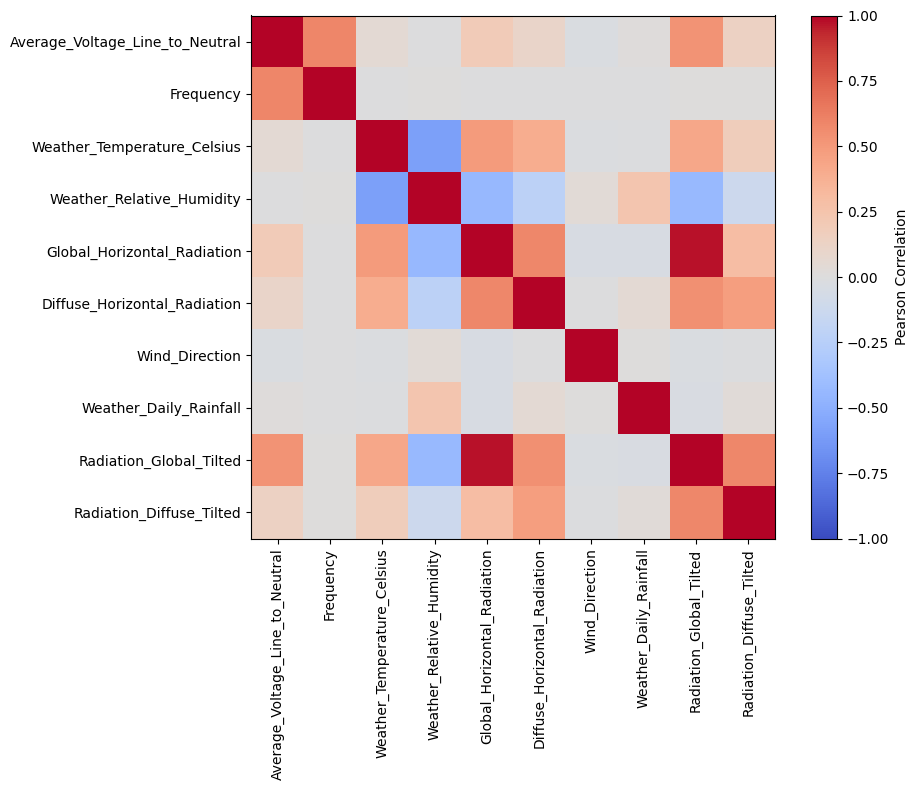

In [19]:
import matplotlib.pyplot as plt

# Visualize correlation among predictor variables.

plt.figure(figsize=(10, 8))

plt.imshow(predictor_correlation, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Pearson Correlation")

plt.xticks(
    range(len(predictor_correlation.columns)),
    predictor_correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(predictor_correlation.columns)),
    predictor_correlation.columns
)

plt.tight_layout()

plt.show()

## Additional Feature Elimination

The following variables are removed based primarily on domain knowledge. Pearson correlation analysis and predictor correlation analysis are used only as supporting evidence and not as the sole basis for feature elimination.

In [20]:
# Frequency shows negligible association with the target and other predictors, indicating minimal predictive contribution to the forecasting task.

df.drop(columns=["Frequency"], inplace=True)

In [21]:
# Voltage reflects grid operating conditions rather than environmental drivers of PV generation. It also showed weak correlation with Active_Power (r = 0.173) despite moderate correlation with Radiation_Global_Tilted (r = 0.526).

df.drop(columns=["Average_Voltage_Line_to_Neutral"], inplace=True)

In [22]:
# Rainfall influences PV output indirectly through atmospheric conditions already captured by irradiance,temperature and humidity. It showed negligible correlation with Active_Power (r = -0.049) and weak interaction with other predictors.

df.drop(columns=["Weather_Daily_Rainfall"], inplace=True)

In [23]:
# Wind direction is not a direct physical driver of PV generation in this study.
# It showed negligible correlation with Active_Power (r = 0.018) and almost no interaction with other predictors.
df.drop(columns=["Wind_Direction"], inplace=True)

In [24]:
for i, col in enumerate(df.columns):
  print(f"{i+1:3d}.{col}")

  1.timestamp
  2.Active_Power
  3.Weather_Temperature_Celsius
  4.Weather_Relative_Humidity
  5.Global_Horizontal_Radiation
  6.Diffuse_Horizontal_Radiation
  7.Radiation_Global_Tilted
  8.Radiation_Diffuse_Tilted


## Identification of Missing Periods

Missing-value blocks are identified to determine whether the missing observations originate from prolonged sensor outages or isolated missing records. This helps decide whether a complete time interval can be removed instead of applying unnecessary imputation.

In [25]:
# Percentage of missing values in each year for ALL remaining features.

remaining_features = [
    "Active_Power",
    "Radiation_Global_Tilted",
    "Radiation_Diffuse_Tilted",
    "Weather_Temperature_Celsius",
    "Weather_Relative_Humidity",
    "Global_Horizontal_Radiation",
    "Diffuse_Horizontal_Radiation",
]

missing_summary = (
    df.assign(Year=df["timestamp"].dt.year)
      .groupby("Year")[remaining_features]
      .apply(lambda x: x.isna().mean() * 100)
      .round(2)
)

display(missing_summary)

,Active_Power,Radiation_Global_Tilted,Radiation_Diffuse_Tilted,Weather_Temperature_Celsius,Weather_Relative_Humidity,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation
Year,,,,,,,
2008,0.0,100.00,100.00,18.33,18.33,18.33,18.33
2009,0.0,100.00,100.00,0.00,0.00,0.00,0.00
2010,0.0,100.00,100.00,0.00,0.00,0.00,0.00
2011,0.0,100.00,100.00,0.54,0.54,0.54,0.54
2012,0.0,100.00,100.00,0.00,0.00,0.00,0.00
2013,0.0,41.80,41.80,0.00,0.00,0.00,0.00
2014,0.0,27.18,2.90,0.00,0.00,0.00,0.00
2015,0.0,16.21,0.42,0.00,0.00,0.00,0.00
2016,0.0,1.31,1.31,0.00,0.00,0.00,0.00


## Removal of Early Years

The years 2008–2013 were removed from the dataset because the combined PV system was still undergoing commissioning and capacity expansion during this period. This was evidenced by the steady increase in yearly maximum power output, average daytime power generation, and annual energy production.

In addition, the tilted irradiance variables (Radiation_Global_Tilted and Radiation_Diffuse_Tilted) exhibited complete or substantial missing observations during these years, indicating prolonged sensor unavailability.

From 2014 onwards, both the installed plant capacity and sensor availability became considerably more stable, making this period more suitable for developing and evaluating a photovoltaic power forecasting model.

In [26]:
# Remove observations recorded before 2014 due to prolonged missingness
# in the tilted irradiance measurements.

df = df[df["timestamp"].dt.year >= 2014].copy()

print(f"Dataset shape after filtering: {df.shape}")

Dataset shape after filtering: (1183924, 8)


***INTERPOLATING MISSING VALUES***

In [27]:
# Fill only short gaps (up to 1 hour = 12 consecutive 5-minute samples).
# Longer gaps are intentionally left as NaN to avoid creating artificial data.

df = df.sort_values("timestamp").set_index("timestamp")

df = df.interpolate(
    method="time",
    limit=12,
    limit_direction="both"
)

df = df.reset_index()

In [28]:
# Remaining missing values correspond to long outages that were not interpolated.

missing_after_interpolation = (
    df.isna().sum()
      .to_frame("Missing Values")
)

display(missing_after_interpolation)

,Missing Values
timestamp,0
Active_Power,0
Weather_Temperature_Celsius,5023
Weather_Relative_Humidity,5023
Global_Horizontal_Radiation,5023
Diffuse_Horizontal_Radiation,5023
Radiation_Global_Tilted,113612
Radiation_Diffuse_Tilted,71468


In [29]:
# Identify the start and end timestamps of the continuous weather-station outage.

weather_gap = df[df["Weather_Temperature_Celsius"].isna()]

print("Start:", weather_gap["timestamp"].min())
print("End  :", weather_gap["timestamp"].max())
print("Rows :", len(weather_gap))

Start: 2025-01-06 19:15:00
End  : 2025-01-27 18:05:00
Rows : 5023


In [30]:
# Remove the continuous weather-station outage (06 Jan 2025 - 27 Jan 2025).
# The outage spans ~21 days (5,023 records), making interpolation unreliable.

df = df[
    ~(
        (df["timestamp"] >= "2025-01-06 19:15:00") &
        (df["timestamp"] <= "2025-01-27 18:05:00")
    )
].reset_index(drop=True)

print(f"Dataset shape after removing weather-station outage: {df.shape}")

Dataset shape after removing weather-station outage: (1178901, 8)


In [31]:
# Remove rows that still contain missing values.
# These correspond to long sensor outages that were intentionally not interpolated.

df = df.dropna().reset_index(drop=True)

print(f"Final dataset shape: {df.shape}")

Final dataset shape: (1065289, 8)


In [32]:
display(df.isna().sum())

timestamp                       0
Active_Power                    0
Weather_Temperature_Celsius     0
Weather_Relative_Humidity       0
Global_Horizontal_Radiation     0
Diffuse_Horizontal_Radiation    0
Radiation_Global_Tilted         0
Radiation_Diffuse_Tilted        0
dtype: int64

**SAVE FINAL DATASET**

In [33]:
from configs import config

config.PROCESSED_DATA_FILE.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(config.PROCESSED_DATA_FILE, index=False)

print("Preprocessed dataset saved successfully.")
print(f"Final dataset shape: {df.shape}")

Preprocessed dataset saved successfully.
Final dataset shape: (1065289, 8)


In [34]:
# Compressed version (recommended for GitHub and faster loading).

df.to_csv("DKASC_Preprocessed.csv.gz", index=False, compression="gzip")